In [15]:
import pandas as pd
import numpy as np
import pickle as pk
from scipy import stats
from matplotlib import pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
from sklearn import clone

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("./"), os.pardir)))
from customFunctions.utils import binary_auROC

In [2]:
tapogee_features = pd.read_csv("../tAPOGEE/checkpoints/mithril_features.csv", sep="\t", index_col="Mithril_id")
tapogee_features

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,bulge,stem,hairpin,loop,unpaired_frequency,closest_modification,closest_modification_2D,OEUF_score
Mithril_id,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.000,3.724,0.117871,0.028169,3.8,0.832225,0.143385,1.0,0.769628,14.0,-0.802033,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1729,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.004435,1.0,0.769628,14.0,-5.816984,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1730,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.019956,1.0,0.769628,14.0,-3.647059,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1731,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.005174,1.0,1.096296,10.0,-5.594591,1,0,1,0,0,0.014503,7,7.0,0.358
MITHRIL.1732,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.477458,1.0,1.096296,10.0,0.933444,1,0,1,0,0,0.014503,7,7.0,0.358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.000,3.604,0.738729,0.000000,0.7,0.956554,0.023564,1.0,0.316291,14.0,-3.407268,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48240,1.000,3.604,0.738729,0.029412,4.7,0.956554,0.004418,1.0,0.316291,14.0,-5.822305,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48241,1.000,5.938,0.734021,0.000000,1.9,0.981591,0.012518,1.0,0.154686,14.0,-4.319805,0,0,1,0,0,0.003610,8,6.0,0.470


In [3]:
tapogee_embedding = pd.read_csv("../tAPOGEE/data/Mithril_msm_embedding.csv", index_col=0)
tapogee_embedding.index.name = "Mithril_id"
tapogee_embedding.columns = "channel_"+tapogee_embedding.columns.astype(str)
tapogee_embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,-0.046571,-0.464829,-1.071173,0.706031,0.254538,-0.839300,-0.785148,-0.686940,-0.066750,-0.083101,...,0.703984,-0.094465,0.001146,-0.474778,0.054920,0.746596,-0.846664,0.056164,0.580686,-0.568011
MITHRIL.1729,-0.094558,-0.843313,-0.774938,0.836958,-0.283595,-0.961378,-0.578084,-0.701949,0.039039,-0.158005,...,0.391420,-0.352180,0.091886,-0.714017,0.015839,0.481953,-0.791229,0.398780,0.376998,0.029397
MITHRIL.1730,0.050315,-0.794720,-0.958813,0.551639,-0.071321,-0.767290,-0.558026,-0.843187,0.249865,-0.380568,...,0.306507,-0.153325,0.306693,-0.223419,-0.042577,0.929070,-0.781954,0.641456,0.126171,0.083980
MITHRIL.1731,-0.271729,-0.401465,-0.722368,0.715860,-0.171587,-0.678559,-0.540892,-0.339579,-0.256668,-0.268223,...,0.985569,0.165077,-0.349262,-0.658368,-0.430892,-0.193119,-0.840392,-0.930292,0.894584,-0.970570
MITHRIL.1732,-0.189935,-0.290123,-0.115013,0.859563,-0.127386,-0.715655,-0.411798,-0.926073,-0.151554,-0.170612,...,1.006938,-0.278918,-0.724813,-0.523815,-0.416955,0.000319,-1.031683,-0.880209,1.119973,-0.960705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,0.085203,0.720789,0.258117,-0.241561,0.276256,0.001175,0.117050,-0.357717,0.238088,0.165467,...,-0.069218,0.467677,-0.082058,0.037380,0.941805,-0.044995,-0.369644,0.526498,-0.601754,-0.447180
MITHRIL.48240,-0.516000,0.442102,0.331330,0.229251,-0.081880,-0.531516,0.226194,-0.564276,0.209845,-0.133919,...,-0.124533,0.285401,-0.201929,-0.403190,0.809152,0.175132,-0.162785,0.336191,-0.763395,-0.056434
MITHRIL.48241,0.318094,0.357954,-0.837745,-0.545639,-0.157910,0.394076,-1.226594,-0.005673,0.406269,-0.306028,...,-0.098943,0.436399,0.025024,1.110456,-0.265077,0.567142,-0.822745,-0.657988,-0.763098,-0.291456


In [4]:
X_tapogee = tapogee_features.join(tapogee_embedding)
X_tapogee.shape

(4521, 788)

In [5]:
y_tapogee = pd.read_csv("../tAPOGEE/data/training_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["benign", "pathogenic"], [0,1])
y_tapogee

/tmp/ipykernel_1063081/2583696874.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["benign", "pathogenic"], [0,1])


Mithril_id
MITHRIL.1744     1
MITHRIL.1753     0
MITHRIL.1770     0
MITHRIL.1772     1
MITHRIL.1773     0
                ..
MITHRIL.48225    0
MITHRIL.48227    0
MITHRIL.48229    0
MITHRIL.48243    0
MITHRIL.48241    1
Name: label, Length: 684, dtype: int64

In [6]:
y_clingen_trna = pd.read_csv("../tAPOGEE/data/test_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["Pathogenic", "Likely pathogenic", "Benign", "Likely benign"], [1,1,0,0])
y_clingen_trna

/tmp/ipykernel_1063081/2020800646.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["Pathogenic", "Likely pathogenic", "Benign", "Likely benign"], [1,1,0,0])


Mithril_id
MITHRIL.1846     1
MITHRIL.4929     1
MITHRIL.9729     1
MITHRIL.9728     1
MITHRIL.9752     1
                ..
MITHRIL.17470    0
MITHRIL.17540    0
MITHRIL.30284    0
MITHRIL.44252    0
MITHRIL.47953    0
Name: label, Length: 71, dtype: int64

In [7]:
tapogee = pk.load(open("../tAPOGEE/checkpoints/candidate_models/model_svc.pk", "rb"))
tapogee

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x7648562ba7a0>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x7648562d7e20>, verbose=2)

In [15]:
tapogee_cv = []
for train, val in tapogee.cv.split(X_tapogee.loc[y_tapogee.index], y_tapogee):
    print("...")
    tapogee_cv.append(
        clone(tapogee.best_estimator_).fit(X_tapogee.loc[y_tapogee.index].iloc[train], y_tapogee.iloc[train])
    )
tapogee_cv

...
...
...
...
...
...
...
...
...
...


[Pipeline(steps=[('input_selection',
                  ColumnTransformerDF(transformers=[('feature_selection',
                                                     SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                        random_state=777),
                                                                       threshold=0.01),
                                                     Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', 'ddG',
        'ref_frequency', 'alt_frequency', 'coverage', 'entropy',
        'conservation_blocks', 'PWM...
                  GridSearchOOB_BinaryClassifier(estimator=BalancedBaggingClassifier(estimator=SVC(C=100,
                                                                                                   gamma=0.01,
                                                                                                  

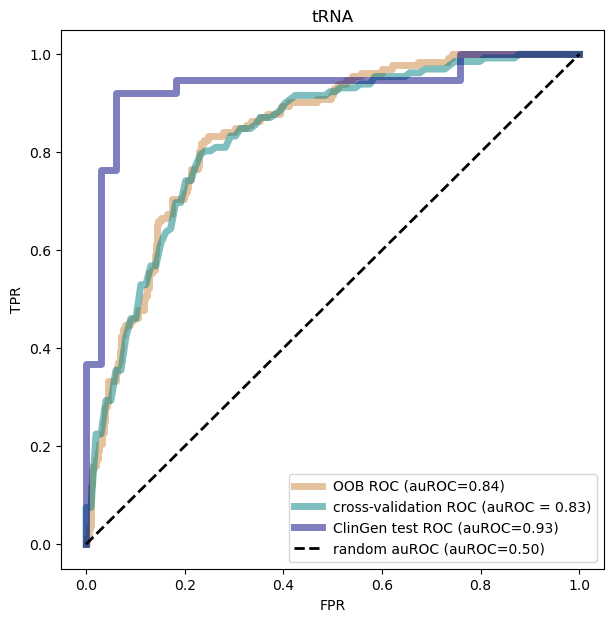

In [18]:
plt.figure(figsize=(7,7))

#################################
############ OOB ROC ############
#################################

fpr, tpr, _ = roc_curve(y_tapogee, tapogee.best_estimator_[-1].estimator.oob_decision_function_[:,1])
plt.plot(
    fpr, tpr,
    label="OOB ROC (auROC=%.2f)"%roc_auc_score(y_tapogee, tapogee.best_estimator_[-1].estimator.oob_decision_function_[:,1]),
    linewidth=5, alpha=.5, color="peru"
)


#################################
############ CV ROC #############
#################################

fpr_bins = np.linspace(0, 1, 100)
tprs = []
aucs = []

for (train, val), cv_model in zip(tapogee.cv.split(X_tapogee.loc[y_tapogee.index], y_tapogee), tapogee_cv):
    fpr, tpr, _ = roc_curve(
        y_tapogee.iloc[val], 
        cv_model.predict_proba(X_tapogee.loc[y_tapogee.index].iloc[val])[:, 1])
    tprs.append(np.interp(fpr_bins, fpr, tpr))
    
    aucs.append(
        roc_auc_score(
            y_tapogee.iloc[val],
            cv_model.predict_proba(X_tapogee.loc[y_tapogee.index].iloc[val])[:, 1]
        )
    )
    
    # plt.plot(fpr, tpr, linewidth=1, alpha=0.5, color="teal")

# Compute mean TPR and standard deviation across folds
fpr_bins = np.concat([[0.], fpr_bins, [1.]])
mean_tpr = np.concat([[0.], np.mean(tprs, axis=0), [1.]])
std_tpr = np.concat([[0.], np.std(tprs, axis=0), [0.]])

mean_auc = np.mean(aucs)
std_auc = np.std(aucs)


# Plot the average ROC curve
plt.plot(fpr_bins, mean_tpr, color="teal",
         label=r"cross-validation ROC (auROC = %0.2f)"%mean_auc,
         lw=5, alpha=.5)



#################################
########### test ROC ############
#################################

fpr, tpr, _ = roc_curve(y_clingen_trna, tapogee.predict_proba(X_tapogee.loc[y_clingen_trna.index])[:, 1])
plt.plot(
    fpr, tpr,
    label="ClinGen test ROC (auROC=%.2f)"%roc_auc_score(y_clingen_trna, tapogee.predict_proba(X_tapogee.loc[y_clingen_trna.index])[:, 1]),
    linewidth=5, alpha=.5, color="navy", linestyle="-"
)


#################################
############ general ############
#################################


plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=2, label="random auROC (auROC=0.50)")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.title("tRNA")
plt.show()

In [8]:
rapogee_features = pd.read_csv("../rAPOGEE/checkpoints/mithril_features.csv", sep="\t", index_col="Mithril_id")
rapogee_features

,PhastCons_100V,PhyloP_100V,MLC_score,closest_modification,closest_modification_2D,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,ddG,x_coord,y_coord,z_coord
Mithril_id,,,,,,,,,,,,,,,
MITHRIL.1941,0.016,-1.211,0.519343,428,68.0,0.063046,0.734159,0.414031,1.007675,5.0,1.554394,0.0,74.989870,3.792304,-17.815130
MITHRIL.1942,0.016,-1.211,0.519343,428,68.0,0.063046,0.027632,0.414031,1.007675,5.0,-3.177276,0.0,74.989870,3.792304,-17.815130
MITHRIL.1943,0.016,-1.211,0.519343,428,68.0,0.063046,0.175004,0.414031,1.007675,5.0,-0.514311,0.0,74.989870,3.792304,-17.815130
MITHRIL.1944,0.984,8.630,0.536906,427,67.0,0.943580,0.005642,0.431192,0.690667,5.0,-5.469367,0.0,78.754455,2.011318,-16.298545
MITHRIL.1945,0.984,8.630,0.536906,427,67.0,0.943580,0.020433,0.431192,0.690667,5.0,-3.612731,0.0,78.754455,2.011318,-16.298545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,0.000,-1.952,0.681815,160,63.0,0.331219,0.227366,0.414689,1.237161,4.0,-0.136909,0.0,-39.321650,77.760650,-31.156100
MITHRIL.9684,0.000,-1.952,0.681815,160,63.0,0.331219,0.035675,0.414689,1.237161,4.0,-2.808957,-0.2,-39.321650,77.760650,-31.156100
MITHRIL.9685,0.000,-0.833,0.709337,161,64.0,0.643931,0.186358,0.284371,0.908297,3.0,-0.423848,0.0,-31.769100,74.606700,-33.021850


In [9]:
rapogee_embedding = pd.read_csv("../rAPOGEE/data/Mithril_embedding_variants_256windows.csv", index_col=0, sep="\t")
rapogee_embedding.index.name = "Mithril_id"
rapogee_embedding.columns = "channel_"+rapogee_embedding.columns.astype(str)
rapogee_embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1941,0.303513,1.383160,0.638585,-0.056332,0.176263,-0.143039,-0.985142,-0.073643,0.336082,-0.599478,...,-0.664787,0.342638,-0.699671,0.348487,0.340148,-0.661547,-0.597864,-0.348987,0.034101,-0.789595
MITHRIL.1942,0.550209,1.220003,0.230237,-0.072172,0.307337,-0.080652,-1.192470,0.338680,0.417476,-0.599843,...,-0.795870,0.374328,-0.212471,0.258718,0.568081,-0.767436,-0.461378,0.112244,-0.375101,-0.613042
MITHRIL.1943,0.459543,1.446819,0.370377,-0.316391,0.367811,0.119868,-0.938122,0.148861,0.658042,-0.837851,...,-0.601526,0.258426,-0.295742,0.531571,0.098219,-0.288436,-0.316600,-0.029138,-0.262222,-0.427665
MITHRIL.1944,0.118863,1.211255,0.680541,0.772733,0.030618,-0.126848,-0.616585,0.319752,0.465699,-0.481459,...,-0.197357,0.359017,-0.049334,-0.141238,-0.017622,0.085889,-0.126867,0.402710,0.525452,0.224361
MITHRIL.1945,0.174472,1.160523,0.451300,0.105366,0.336155,-0.178989,-0.596600,0.255072,0.611938,-0.435275,...,-0.372028,0.596866,0.099172,0.075484,-0.035451,-0.114921,-0.501647,0.671988,0.081063,-0.250176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,0.718890,0.957562,0.375530,1.028451,0.426534,-0.871481,-0.440027,-0.612123,-0.065064,-0.365776,...,0.180092,0.376471,-0.410671,-0.552921,0.194272,-0.247190,-0.207616,-0.102479,0.734206,-0.471182
MITHRIL.9684,0.859912,0.645613,-0.226261,0.669992,0.278951,-0.784824,-0.595451,-0.105677,-0.029068,-0.408974,...,-0.045239,0.154268,0.257173,-0.739464,0.196565,-0.440911,-0.431372,0.007138,0.411753,-0.449467
MITHRIL.9685,0.567578,0.794154,0.440818,0.410750,0.398513,-0.607294,-0.894730,-0.127402,0.098248,-0.188302,...,0.814643,-0.055371,0.330179,-0.671677,0.158416,-0.441889,-0.294790,-0.144047,0.570522,-0.642164


In [10]:
X_rapogee = rapogee_features.join(rapogee_embedding)
X_rapogee.shape

(7536, 783)

In [11]:
y_rapogee = pd.read_csv("../rAPOGEE/data/training_test_set_unified.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["benign", "likely benign", "likely pathogenic", "pathogenic"], [0, 0, 1, 1])
y_rapogee

/tmp/ipykernel_1063081/3989947379.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["benign", "likely benign", "likely pathogenic", "pathogenic"], [0, 0, 1, 1])


Mithril_id
MITHRIL.1942    0
MITHRIL.1948    0
MITHRIL.1955    0
MITHRIL.1958    0
MITHRIL.1960    0
               ..
MITHRIL.9638    0
MITHRIL.9650    0
MITHRIL.9659    0
MITHRIL.9662    0
MITHRIL.9678    0
Name: label, Length: 1078, dtype: int64

In [12]:
rapogee = pk.load(open("../rAPOGEE/checkpoints/candidate_models/model_rf.pk", "rb"))
rapogee

Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'closest_modification',
       'closest_modification_2D', 'ref_frequency', 'alt_frequency', 'coverage',
       'entropy'...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedRandomForestClassifier(bootstrap=True,
                                                                                         criterion='entropy',
                                                                                         max_depth=9,
                                                                                         max_features=0.1,
                                                                                         n_estimators=4096,
                                                                                         n_jobs=-1,
                                                                                         oob_score=True,
                                                                                         sampling_strategy={0: 22,
                                                                                                            1: 22}),
                                                n_jobs=16,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x764848436350>,
                                                scoring_function=<function roc_auc_score at 0x7648562ba7a0>,
                                                verbose=99))])

In [13]:
y_rapogee_cv, pred_rapogee_cv = pk.load(open("../rAPOGEE/checkpoints/cross_validation_test.pk", "rb"))
y_rapogee_cv, pred_rapogee_cv


([Mithril_id
  MITHRIL.2036    0
  MITHRIL.2168    0
  MITHRIL.2437    0
  MITHRIL.2463    0
  MITHRIL.2876    0
  MITHRIL.2895    0
  MITHRIL.3005    0
  MITHRIL.3051    0
  MITHRIL.3352    0
  MITHRIL.3970    0
  MITHRIL.4022    0
  MITHRIL.4493    0
  MITHRIL.4730    1
  MITHRIL.4753    0
  MITHRIL.4782    0
  MITHRIL.4786    0
  MITHRIL.5368    0
  MITHRIL.5419    0
  MITHRIL.5524    0
  MITHRIL.5604    0
  MITHRIL.5672    0
  MITHRIL.5670    0
  MITHRIL.5742    0
  MITHRIL.5862    0
  MITHRIL.5881    0
  MITHRIL.5929    0
  MITHRIL.6103    0
  MITHRIL.6165    0
  MITHRIL.6478    0
  MITHRIL.6727    0
  MITHRIL.7133    0
  MITHRIL.7147    0
  MITHRIL.7157    0
  MITHRIL.7164    0
  MITHRIL.7239    0
  MITHRIL.7268    0
  MITHRIL.7324    0
  MITHRIL.7691    0
  MITHRIL.7912    0
  MITHRIL.8116    0
  MITHRIL.8651    0
  MITHRIL.8710    0
  MITHRIL.8911    0
  MITHRIL.9298    0
  MITHRIL.9593    0
  Name: label, dtype: int64,
  Mithril_id
  MITHRIL.2095    0
  MITHRIL.2114    0
  MIT

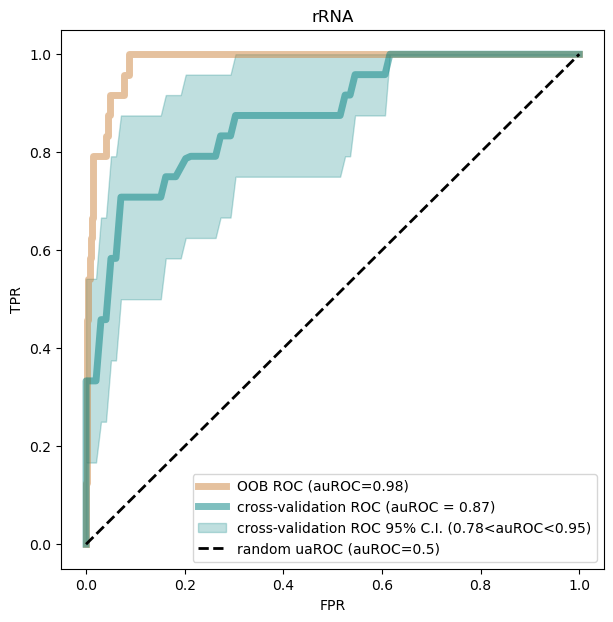

In [14]:
plt.figure(figsize=(7,7))


#################################
############ OOB ROC ############
#################################

fpr, tpr, _ = roc_curve(y_rapogee, rapogee[-1].estimator.oob_decision_function_[:,1])
plt.plot(
    fpr, tpr,
    label="OOB ROC (auROC=%.2f)"%roc_auc_score(y_rapogee, rapogee[-1].estimator.oob_decision_function_[:,1]),
    linewidth=5, alpha=.5, color="peru"
)


#################################
############ CV ROC #############
#################################

fpr_bins = np.linspace(0, 1, 100)
tprs = []
aucs = []

for y_true, y_pred in zip(y_rapogee_cv, pred_rapogee_cv):
    fpr, tpr, _ = roc_curve(
        y_true, y_pred
    )
    tprs.append(np.interp(fpr_bins, fpr, tpr))
    
    aucs.append(
        roc_auc_score(
            y_true, y_pred
        )
    )
    
    #plt.plot(fpr, tpr, linewidth=1, alpha=0.5, color="teal")

# Compute mean TPR and standard deviation across folds
fpr_bins = np.concat([[0.], fpr_bins, [1.]])
mean_tpr = np.concat([[0.], np.mean(tprs, axis=0), [1.]])
std_tpr = np.concat([[0.], np.std(tprs, axis=0), [0.]])

mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

# here we can do a binom conf interval since:
# ther's just one positive sample per fold -> tpr is in {0, 1} -> tpr is a bernoulli variable
low_tprs, high_tprs = stats.binom(24, (np.array(tprs)>=.5).mean(axis=0)).ppf([[.025], [.975]])/24
low_tprs = np.concat([[0.], low_tprs, [1.]])
high_tprs = np.concat([[0.], high_tprs, [1.]])


# Plot the average ROC curve
plt.plot(fpr_bins, mean_tpr, color="teal",
         label=r"cross-validation ROC (auROC = %0.2f)"%mean_auc,
         lw=5, alpha=.5)

plt.fill_between(
    fpr_bins, low_tprs, high_tprs,
    color="teal", alpha=.25,
    label="cross-validation ROC 95%% C.I. (%.2f<auROC<%.2f)"%(low_tprs.mean(), high_tprs.mean())
)


#################################
############ general ############
#################################


plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=2, label="random uaROC (auROC=0.5)")

plt.title("rRNA")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

In [20]:
rapogee_cv_ap = np.array([average_precision_score(y_true, y_pred) for y_true, y_pred in zip(y_rapogee_cv, pred_rapogee_cv)])
rapogee_cv_ap, rapogee_cv_ap.mean()

(array([1.        , 0.03571429, 0.25      , 1.        , 0.25      ,
        1.        , 0.04166667, 0.25      , 1.        , 0.33333333,
        0.125     , 1.        , 0.1       , 0.07142857, 1.        ,
        0.07692308, 0.5       , 0.04      , 0.33333333, 1.        ,
        0.5       , 0.33333333, 0.5       , 1.        ]),
 np.float64(0.4891971916971916))

In [25]:
np.quantile(rapogee_cv_ap, [0.025, .975])

array([0.03817857, 1.        ])

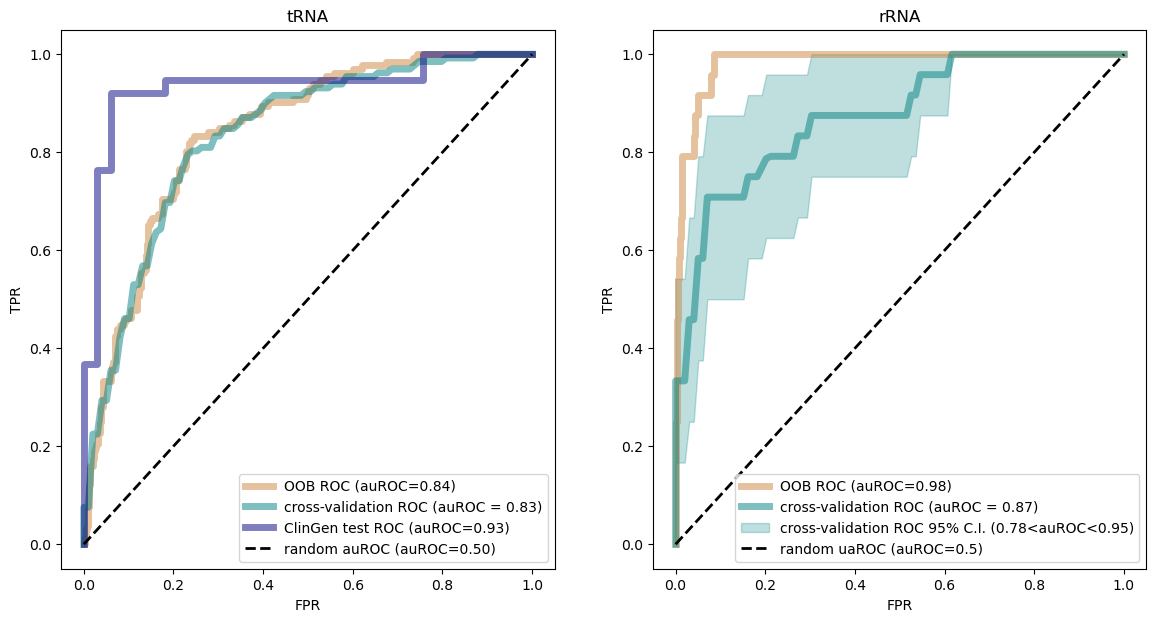

In [41]:
plt.figure(figsize=(14,7))



################################# tAPOGEE #################################
plt.subplot(1,2,1)


#################################
############ OOB ROC ############
#################################

fpr, tpr, _ = roc_curve(y_tapogee, tapogee.best_estimator_[-1].estimator.oob_decision_function_[:,1])
plt.plot(
    fpr, tpr,
    label="OOB ROC (auROC=%.2f)"%roc_auc_score(y_tapogee, tapogee.best_estimator_[-1].estimator.oob_decision_function_[:,1]),
    linewidth=5, alpha=.5, color="peru"
)


#################################
############ CV ROC #############
#################################

fpr_bins = np.linspace(0, 1, 100)
tprs = []
aucs = []

for (train, val), cv_model in zip(tapogee.cv.split(X_tapogee.loc[y_tapogee.index], y_tapogee), tapogee_cv):
    fpr, tpr, _ = roc_curve(
        y_tapogee.iloc[val], 
        cv_model.predict_proba(X_tapogee.loc[y_tapogee.index].iloc[val])[:, 1])
    tprs.append(np.interp(fpr_bins, fpr, tpr))
    
    aucs.append(
        roc_auc_score(
            y_tapogee.iloc[val],
            cv_model.predict_proba(X_tapogee.loc[y_tapogee.index].iloc[val])[:, 1]
        )
    )
    
    # plt.plot(fpr, tpr, linewidth=1, alpha=0.5, color="teal")

# Compute mean TPR and standard deviation across folds
fpr_bins = np.concat([[0.], fpr_bins, [1.]])
mean_tpr = np.concat([[0.], np.mean(tprs, axis=0), [1.]])
std_tpr = np.concat([[0.], np.std(tprs, axis=0), [0.]])

mean_auc = np.mean(aucs)
std_auc = np.std(aucs)


# Plot the average ROC curve
plt.plot(fpr_bins, mean_tpr, color="teal",
         label=r"cross-validation ROC (auROC = %0.2f)"%mean_auc,
         lw=5, alpha=.5)



#################################
########### test ROC ############
#################################

fpr, tpr, _ = roc_curve(y_clingen_trna, tapogee.predict_proba(X_tapogee.loc[y_clingen_trna.index])[:, 1])
plt.plot(
    fpr, tpr,
    label="ClinGen test ROC (auROC=%.2f)"%roc_auc_score(y_clingen_trna, tapogee.predict_proba(X_tapogee.loc[y_clingen_trna.index])[:, 1]),
    linewidth=5, alpha=.5, color="navy", linestyle="-"
)




#################################
############ general ############
#################################


plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=2, label="random auROC (auROC=0.50)")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.title("tRNA")


################################# rAPOGEE #################################
plt.subplot(1,2,2)


#################################
############ OOB ROC ############
#################################

fpr, tpr, _ = roc_curve(y_rapogee, rapogee[-1].estimator.oob_decision_function_[:,1])
plt.plot(
    fpr, tpr,
    label="OOB ROC (auROC=%.2f)"%roc_auc_score(y_rapogee, rapogee[-1].estimator.oob_decision_function_[:,1]),
    linewidth=5, alpha=.5, color="peru"
)


#################################
############ CV ROC #############
#################################

fpr_bins = np.linspace(0, 1, 100)
tprs = []
aucs = []

for y_true, y_pred in zip(y_rapogee_cv, pred_rapogee_cv):
    fpr, tpr, _ = roc_curve(
        y_true, y_pred
    )
    tprs.append(np.interp(fpr_bins, fpr, tpr))
    
    aucs.append(
        roc_auc_score(
            y_true, y_pred
        )
    )
    

# Compute mean TPR and standard deviation across folds
fpr_bins = np.concat([[0.], fpr_bins, [1.]])
mean_tpr = np.concat([[0.], np.mean(tprs, axis=0), [1.]])
std_tpr = np.concat([[0.], np.std(tprs, axis=0), [0.]])

mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

# here we can do a binom conf interval since:
# ther's just one positive sample per fold -> tpr is in {0, 1} -> tpr is a bernoulli variable
low_tprs, high_tprs = stats.binom(24, (np.array(tprs)>=.5).mean(axis=0)).ppf([[.025], [.975]])/24
low_tprs = np.concat([[0.], low_tprs, [1.]])
high_tprs = np.concat([[0.], high_tprs, [1.]])


# Plot the average ROC curve
plt.plot(fpr_bins, mean_tpr, color="teal",
         label=r"cross-validation ROC (auROC = %0.2f)"%mean_auc,
         lw=5, alpha=.5)

plt.fill_between(
    fpr_bins, low_tprs, high_tprs,
    color="teal", alpha=.25,
    label="cross-validation ROC 95%% C.I. (%.2f<auROC<%.2f)"%(low_tprs.mean(), high_tprs.mean())
)


#################################
############ general ############
#################################


plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=2, label="random uaROC (auROC=0.5)")

plt.title("rRNA")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()


plt.savefig("svg/ROC_curves.svg")
plt.show()